In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import mediapipe as mp

from mediapipe.tasks import python
from mediapipe.tasks.python import vision


# Dataset path
DATASET_PATH = "dataset/ASL_Dataset/dataset"

# MediaPipe model
MODEL_PATH = "models/hand_landmarker.task"

print("Dataset path:", DATASET_PATH)
print("Model path:", MODEL_PATH)

print("\nClasses found:")
print(os.listdir(DATASET_PATH))

Dataset path: dataset/ASL_Dataset/dataset
Model path: models/hand_landmarker.task

Classes found:
['A-samples', 'B-samples', 'C-samples', 'D-samples', 'E-samples', 'F-samples', 'G-samples', 'I-samples', 'K-samples', 'L-samples', 'M-samples', 'N-samples', 'O-samples', 'P-samples', 'Q-samples', 'R-samples', 'S-samples', 'T-samples', 'U-samples', 'V-samples', 'W-samples', 'X-samples', 'Y-samples']


In [2]:
# Create MediaPipe Hand Landmarker

base_options = python.BaseOptions(
    model_asset_path=MODEL_PATH
)

options = vision.HandLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.IMAGE,
    num_hands=1,
    min_hand_detection_confidence=0.5,
    min_hand_presence_confidence=0.5,
    min_tracking_confidence=0.5
)

landmarker = vision.HandLandmarker.create_from_options(
    options
)

print("✅ MediaPipe Hand Landmarker created successfully!")

✅ MediaPipe Hand Landmarker created successfully!


In [3]:
# Extract MediaPipe landmarks from the complete dataset

data = []

# Get all class folders
class_folders = sorted(os.listdir(DATASET_PATH))

for class_folder in class_folders:

    class_path = os.path.join(
        DATASET_PATH,
        class_folder
    )

    # Make sure it is a folder
    if not os.path.isdir(class_path):
        continue

    # Label = A, B, C ... Z
    label = class_folder.replace("-samples", "")

    print(f"Processing class: {label}")

    # Process every image
    for image_name in os.listdir(class_path):

        if not image_name.lower().endswith(
            (".jpg", ".jpeg", ".png")
        ):
            continue

        image_path = os.path.join(
            class_path,
            image_name
        )

        # Read image
        image = cv2.imread(image_path)

        if image is None:
            print(f"⚠️ Could not read: {image_name}")
            continue

        # BGR → RGB
        rgb_image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        # Convert to MediaPipe image
        mp_image = mp.Image(
            image_format=mp.ImageFormat.SRGB,
            data=rgb_image
        )

        # Detect hand
        result = landmarker.detect(mp_image)

        # Check whether a hand was detected
        if len(result.hand_landmarks) == 0:
            continue

        # Take first hand
        landmarks = result.hand_landmarks[0]

        # Extract x, y, z
        features = []

        for landmark in landmarks:

            features.extend([
                landmark.x,
                landmark.y,
                landmark.z
            ])

        # Add label
        features.append(label)

        data.append(features)


print("\n===================================")
print("✅ Landmark extraction completed!")
print("===================================")

print("Total samples:", len(data))
print("Features per sample:", len(data[0]) - 1)

Processing class: A


c:\Users\DELL\OneDrive\Desktop\ASL_DL\venv\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


Processing class: B
Processing class: C
Processing class: D
Processing class: E
Processing class: F
Processing class: G
Processing class: I
Processing class: K
Processing class: L
Processing class: M
Processing class: N
Processing class: O
Processing class: P
Processing class: Q
Processing class: R
Processing class: S
Processing class: T
Processing class: U
Processing class: V
Processing class: W
Processing class: X
Processing class: Y

✅ Landmark extraction completed!
Total samples: 2294
Features per sample: 63


In [4]:
# Convert extracted landmark data into a DataFrame

feature_columns = []

for i in range(21):
    feature_columns.extend([
        f"x{i}",
        f"y{i}",
        f"z{i}"
    ])

feature_columns.append("label")

df = pd.DataFrame(
    data,
    columns=feature_columns
)

print("Dataset shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (2294, 64)

First 5 rows:


,x0,y0,z0,x1,y1,z1,x2,y2,z2,x3,...,x18,y18,z18,x19,y19,z19,x20,y20,z20,label
0,0.464024,0.778100,-4.469892e-07,0.604838,0.715023,-0.028468,0.690806,0.579886,-0.028771,0.708798,...,0.387023,0.470609,-0.057896,0.400746,0.538287,-0.040640,0.407014,0.563492,-0.023468,A
1,0.464024,0.778100,-4.469892e-07,0.604838,0.715023,-0.028468,0.690806,0.579886,-0.028771,0.708798,...,0.387023,0.470609,-0.057896,0.400746,0.538287,-0.040640,0.407014,0.563492,-0.023468,A
2,0.329475,0.932694,-4.302106e-07,0.456634,0.853280,-0.022263,0.520472,0.715620,-0.023177,0.530866,...,0.236885,0.657858,-0.051270,0.252765,0.707308,-0.042012,0.262709,0.731750,-0.032188,A
3,0.531410,0.953215,-8.027520e-07,0.699454,0.899211,-0.028708,0.819744,0.754861,-0.031031,0.856431,...,0.480354,0.582820,-0.082048,0.482903,0.667195,-0.055690,0.479147,0.683132,-0.032397,A
4,0.329475,0.932694,-4.302106e-07,0.456634,0.853280,-0.022263,0.520472,0.715620,-0.023177,0.530866,...,0.236885,0.657858,-0.051270,0.252765,0.707308,-0.042012,0.262709,0.731750,-0.032188,A


In [5]:
# Check number of samples in each class

print(df["label"].value_counts().sort_index())

label
A    101
B    101
C    102
D    102
E    101
F    102
G    101
I    100
K    101
L    100
M     96
N     98
O    100
P     99
Q    101
R     97
S     99
T    100
U     97
V     96
W     98
X    102
Y    100
Name: count, dtype: int64


In [6]:
# Save the extracted landmark dataset

OUTPUT_PATH = "output/asl_landmarks.csv"

df.to_csv(
    OUTPUT_PATH,
    index=False
)

print(f"✅ Dataset saved successfully!")
print(f"📁 Saved to: {OUTPUT_PATH}")
print(f"📊 Shape: {df.shape}")

✅ Dataset saved successfully!
📁 Saved to: output/asl_landmarks.csv
📊 Shape: (2294, 64)


In [7]:
# Verify the saved dataset

saved_df = pd.read_csv(OUTPUT_PATH)

print("Dataset loaded successfully!")
print("Shape:", saved_df.shape)
print("\nColumns:")
print(saved_df.columns.tolist())

Dataset loaded successfully!
Shape: (2294, 64)

Columns:
['x0', 'y0', 'z0', 'x1', 'y1', 'z1', 'x2', 'y2', 'z2', 'x3', 'y3', 'z3', 'x4', 'y4', 'z4', 'x5', 'y5', 'z5', 'x6', 'y6', 'z6', 'x7', 'y7', 'z7', 'x8', 'y8', 'z8', 'x9', 'y9', 'z9', 'x10', 'y10', 'z10', 'x11', 'y11', 'z11', 'x12', 'y12', 'z12', 'x13', 'y13', 'z13', 'x14', 'y14', 'z14', 'x15', 'y15', 'z15', 'x16', 'y16', 'z16', 'x17', 'y17', 'z17', 'x18', 'y18', 'z18', 'x19', 'y19', 'z19', 'x20', 'y20', 'z20', 'label']


In [8]:
# Separate input features and target labels

X = df.drop("label", axis=1)
y = df["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nLabels:")
print(y.unique())

X shape: (2294, 63)
y shape: (2294,)

Labels:
['A' 'B' 'C' 'D' 'E' 'F' 'G' 'I' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R' 'S' 'T'
 'U' 'V' 'W' 'X' 'Y']


In [9]:
from sklearn.preprocessing import LabelEncoder

# Encode A-Z into numbers

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Encoded labels:")
print(y_encoded[:20])

print("\nClass names:")
print(label_encoder.classes_)

Encoded labels:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

Class names:
['A' 'B' 'C' 'D' 'E' 'F' 'G' 'I' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R' 'S' 'T'
 'U' 'V' 'W' 'X' 'Y']


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (1835, 63)
Testing data: (459, 63)


In [11]:
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same scaler
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (1835, 63)
X_test_scaled shape: (459, 63)


In [12]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Create ANN model
model = Sequential([
    
    Dense(128, activation="relu", input_shape=(63,)),
    
    Dense(64, activation="relu"),
    
    Dropout(0.3),
    
    Dense(32, activation="relu"),
    
    Dense(26, activation="softmax")
])

# Display model architecture
model.summary()

c:\Users\DELL\OneDrive\Desktop\ASL_DL\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 26)             │           858 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,386 (75.73 KB)

 Trainable params: 19,386 (75.73 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("✅ ANN compiled successfully!")

✅ ANN compiled successfully!


In [14]:
from tensorflow.keras.callbacks import EarlyStopping

# Stop training if validation loss stops improving
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

# Train ANN
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.1199 - loss: 3.0328 - val_accuracy: 0.2752 - val_loss: 2.6960
Epoch 2/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3474 - loss: 2.3605 - val_accuracy: 0.5531 - val_loss: 1.7934
Epoch 3/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5307 - loss: 1.5698 - val_accuracy: 0.7548 - val_loss: 1.0354
Epoch 4/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6948 - loss: 0.9932 - val_accuracy: 0.8365 - val_loss: 0.6688
Epoch 5/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7793 - loss: 0.7310 - val_accuracy: 0.8747 - val_loss: 0.5330
Epoch 6/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8345 - loss: 0.5372 - val_accuracy: 0.9019 - val_loss: 0.3887
Epoch 7/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8638 - loss: 0.4462 - val_accuracy: 0.9210 - val_loss: 0.3235
Epoch 8/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8944 - loss: 0.3679 - val_accuracy: 0.

In [15]:
# Evaluate the ANN on the unseen test set

test_loss, test_accuracy = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=1
)

print("\n==============================")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print("==============================")

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9913 - loss: 0.0623

Test Loss: 0.0623
Test Accuracy: 0.9913
Test Accuracy: 99.13%


In [16]:
from sklearn.metrics import classification_report

# Predict test data
y_pred_prob = model.predict(
    X_test_scaled,
    verbose=0
)

y_pred = np.argmax(
    y_pred_prob,
    axis=1
)

# Classification report
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

           A       1.00      1.00      1.00        20
           B       1.00      1.00      1.00        20
           C       1.00      1.00      1.00        20
           D       1.00      1.00      1.00        21
           E       1.00      1.00      1.00        20
           F       1.00      1.00      1.00        21
           G       1.00      1.00      1.00        20
           I       1.00      1.00      1.00        20
           K       1.00      1.00      1.00        20
           L       1.00      1.00      1.00        20
           M       1.00      1.00      1.00        19
           N       0.95      1.00      0.98        20
           O       1.00      0.95      0.97        20
           P       1.00      1.00      1.00        20
           Q       0.91      1.00      0.95        20
           R       1.00      1.00      1.00        19
           S       0.95      1.00      0.98        20
           T       1.00    

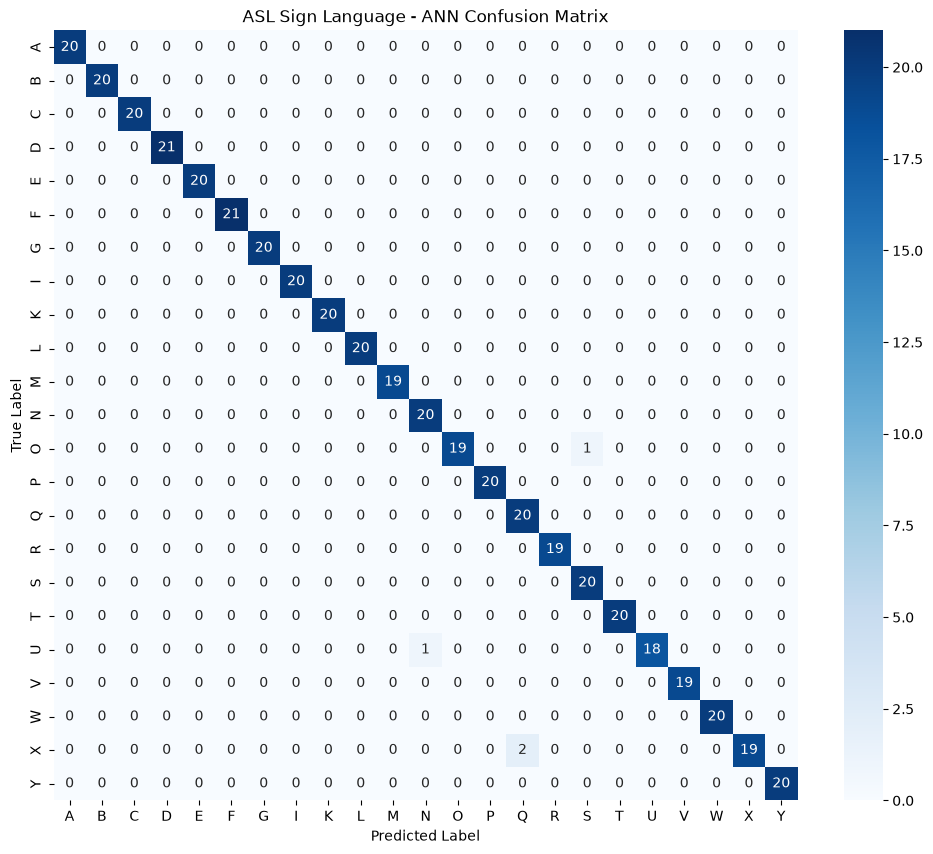

In [17]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("ASL Sign Language - ANN Confusion Matrix")

plt.show()

In [18]:
# Save the trained ANN model

MODEL_OUTPUT = "output/asl_ann_model.keras"

model.save(MODEL_OUTPUT)

print("✅ ANN model saved successfully!")
print("📁", MODEL_OUTPUT)

✅ ANN model saved successfully!
📁 output/asl_ann_model.keras


In [19]:
import joblib

SCALER_OUTPUT = "output/scaler.pkl"

joblib.dump(
    scaler,
    SCALER_OUTPUT
)

print("✅ Scaler saved successfully!")
print("📁", SCALER_OUTPUT)

✅ Scaler saved successfully!
📁 output/scaler.pkl


In [20]:
LABEL_ENCODER_OUTPUT = "output/label_encoder.pkl"

joblib.dump(
    label_encoder,
    LABEL_ENCODER_OUTPUT
)

print("✅ Label encoder saved successfully!")
print("📁", LABEL_ENCODER_OUTPUT)

✅ Label encoder saved successfully!
📁 output/label_encoder.pkl


In [1]:
# Test the saved ANN model

from tensorflow.keras.models import load_model
import joblib
import numpy as np

# Load saved files
loaded_model = load_model("output/asl_ann_model.keras")
loaded_scaler = joblib.load("output/scaler.pkl")
loaded_encoder = joblib.load("output/label_encoder.pkl")

print("✅ ANN model loaded")
print("✅ Scaler loaded")
print("✅ Label encoder loaded")

✅ ANN model loaded
✅ Scaler loaded
✅ Label encoder loaded


In [3]:
import cv2
import numpy as np
import mediapipe as mp
import joblib

from mediapipe.tasks import python
from mediapipe.tasks.python import vision

from tensorflow.keras.models import load_model

In [4]:
MODEL_PATH = "models/hand_landmarker.task"

base_options = python.BaseOptions(
    model_asset_path=MODEL_PATH
)

options = vision.HandLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.IMAGE,
    num_hands=1,
    min_hand_detection_confidence=0.5,
    min_hand_presence_confidence=0.5,
    min_tracking_confidence=0.5
)

landmarker = vision.HandLandmarker.create_from_options(
    options
)

print("✅ MediaPipe Hand Landmarker ready!")

✅ MediaPipe Hand Landmarker ready!


In [5]:
loaded_model = load_model(
    "output/asl_ann_model.keras"
)

loaded_scaler = joblib.load(
    "output/scaler.pkl"
)

loaded_encoder = joblib.load(
    "output/label_encoder.pkl"
)

print("✅ ANN model loaded")
print("✅ Scaler loaded")
print("✅ Label encoder loaded")

✅ ANN model loaded
✅ Scaler loaded
✅ Label encoder loaded


In [6]:
# Complete inference test:
# Image → MediaPipe → 63 landmarks → Scaler → ANN → Letter

IMAGE_PATH = "dataset/ASL_Dataset/dataset/A-samples/0.jpg"

# Read image
image = cv2.imread(IMAGE_PATH)

if image is None:
    print("❌ Image could not be loaded.")
else:
    # Convert BGR → RGB
    rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Convert to MediaPipe image
    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=rgb_image
    )

    # Detect hand
    result = landmarker.detect(mp_image)

    if len(result.hand_landmarks) == 0:
        print("❌ No hand detected.")

    else:
        # Get first hand
        landmarks = result.hand_landmarks[0]

        # Extract 63 features
        features = []

        for landmark in landmarks:
            features.extend([
                landmark.x,
                landmark.y,
                landmark.z
            ])

        # Convert to NumPy and reshape
        features = np.array(
            features,
            dtype=np.float32
        ).reshape(1, -1)

        # Scale using saved scaler
        features_scaled = loaded_scaler.transform(features)

        # Predict using saved ANN
        probabilities = loaded_model.predict(
            features_scaled,
            verbose=0
        )

        # Get predicted class index
        predicted_index = np.argmax(probabilities)

        # Convert number → letter
        predicted_letter = loaded_encoder.inverse_transform(
            [predicted_index]
        )[0]

        # Confidence
        confidence = probabilities[0][predicted_index] * 100

        print("================================")
        print("✅ Prediction successful!")
        print("Predicted letter:", predicted_letter)
        print(f"Confidence: {confidence:.2f}%")
        print("================================")

c:\Users\DELL\OneDrive\Desktop\ASL_DL\venv\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
c:\Users\DELL\OneDrive\Desktop\ASL_DL\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


✅ Prediction successful!
Predicted letter: A
Confidence: 99.94%
